---
title: "注意力机制(1)"
description: "本文是基于李沐的动手学深度学习课程的一些笔记与个人见解"
date: 2026-08-19
categories:
  - attention
  - Deep Learning

format:
  html:
    toc: true
    toc-depth: 3
    code-fold: true
    code-tools: true
---

## 注意力机制

### 为什么需要注意力机制

与我们的传统的Seq2Seq模型有关，假如我们要做机器翻译从"I Love You"翻译成"我爱你" 

传统的Encoder-Decoder的想法是：

把整个句子"I Love You"压缩成一个固定长度的向量： $c$，例如假设Encoder是一个没有输出的RNN模型，有N层隐藏层， $c$就是第N层隐藏层的最后一步的隐藏单元。

然后Decoder根据这个向量与初始设定的输入，一个词一个词地生成结果"我→爱→你"

但是，如果我们输入的是一串几百个词呢？我们的Encoder必须把整个句子压缩成一个固定大小的向量，这就好像你把500页的书总结出100字的句子一样，信息一定会有损失。所以我们想，为什么 Decoder 不能在生成每一个词的时候，回头看看 Encoder 的所有输出？

假设 Encoder 读完整句话后，产生：
$$h_1, h_2,···，h_T$$
每个$h_i$对应输入序列中的一个位置。

例如,$I|Love|You$可以分为三个部分，得到了$h_1,h_2,h_3$

现在Decoder要生成"我"，他可以问，我现在重点要参考Encoder里的哪几个位置？

于是计算了$[\alpha_1, \alpha_2, \alpha_3]$，比如[0.8, 0.1, 0.1]，那么新的上下文向量就是$c=0.8h_1+0.1h_2+0.1h_3$

这意味着，生成第一个词的时候，主要关注第一个输入词，后面也一样。

### 生物学中的注意力提示

此处我们以D2L课程的举例为开始。我们先思考，注意力机制是如何应用在我们的视觉系统的呢？

此处我们引出一个(two-component)的框架，在这个框架中，我们总是基于**非自主提示**与**自主性提示**有选择地引导我们的注意力的焦点。

下面我们将以一个经典案例来解释这两个提示，想象一下，在你面前的桌子上有五个物品，一份报纸，一篇研究论文，一杯咖啡，一本笔记本和一本书，其中除了咖啡杯是红色以外，其他物品都是黑白颜色的。

1. **非自主提示**是基于环境中物品本身的突出性与易见性。在上面这个案例中，显然红色的咖啡杯是最显眼的，不自主的引起人们的注意力，所以我们会把我们的注意力放到咖啡杯上。\
![](./imgs/24.svg)

2. 当我们喝完咖啡以后，可能想要开始读书了，这时候我们就选择把我们的注意力放到书本上了，此时选择书是受到了认知和意识的影响，因此注意力是在基于**自主性提示**去辅助我们的选择。\
![](./imgs/25.svg)

其实，我们可以用一个非常简单的例子来建立对注意力机制的直观认识。

假如现在有 5 个数字：$[0.1,\ 0.2,\ 10,\ 0.3,\ 0.4]$

如果我们不对其中任何一个数字给予特殊关注，而是给它们分配相同的权重，例如都为 0.2，那么将这些数字进行加权求和：$0.1\times0.2+0.2\times0.2+10\times0.2+0.3\times0.2+0.4\times0.2=2.02$

此时，每个数字获得的权重都是相同的，也就是说，我们并没有特别“关注”其中的某一个数字。

但如果我们改变这些权重，例如希望最终得到的信息更多地受到 0.4 的影响，于是将 0.4 对应的权重提高到 0.96，而其余四个数字的权重分别降低到 0.01：$[0.01,\ 0.01,\ 0.01,\ 0.01,\ 0.96]$

那么再次进行加权求和：$0.1\times0.01+0.2\times0.01+10\times0.01+0.3\times0.01+0.4\times0.96=0.49$可以看到，即使原来的数字中存在一个远大于其他数字的 10，通过调整权重，我们仍然可以显著降低它对最终结果的影响，同时让结果更多地受到 0.4 的影响。

这就是理解注意力机制时一个非常重要的直觉：我们可以通过给不同的信息分配不同的权重，来控制不同信息对最终结果的影响程度。权重越高的信息，就越受到“关注”。注意力就是给不同信息分配不同权重，然后做加权平均

当然，在真正的注意力机制中，这些权重通常并不是由我们手动指定的，而是由模型根据当前任务以及不同信息之间的相关性自动计算出来的。这里的例子只是帮助我们先建立一个直观认识：所谓“注意力”，可以理解为让模型学会把有限的关注分配给不同的信息。

### QKV

下面我们将讲解一下,是如何基于人类的注意力系统,用深度学习来设计注意力机制的框架.

之前学习的卷积、全连接、池化层都只考虑“不随意线索”.

注意力机制则考虑“随意线索”，随意线索被称之为查询(query)，也就是当前需要处理的任务（如翻译中的目标词）。每个输入是一个值(value)和不随意线索(key)的对，通过注意力池化层来有偏向性的选择选择某些输入。而key就代表输入数据的特征表示（如源语言词的编码），Value通常与Key相同，是实际用于生成输出的信息。注意力权重通过Query和Key的相似度计算，然后加权求和Value得到输出。\
![](./imgs/26.svg)


如何理解QKV呢?

首先,我们假设我们有3个key-value对:
<div align="center">
<img src="./imgs/27.png" width="400" height="300" >
</div>
假设存在一个q=57,我们想要知道他应该的体重是多少,我们会怎么求?

按照常理来说,由于57是56与58的中间值,故会觉得,体重应当也为$v_2$与$v_3$的中间值,即$43\times0.5+48\times0.5=45.5$,但是这种情况下,我们好像没有给$v_1$注意力权重了.这显然是不适合的.这边先引出注意力权重,其即为与值相乘的选中,累加后为我们的输入.不是我们人为选择离 57 最近的两个点，而是让所有 Value 都参与，通过注意力权重自动让不相关的信息贡献趋近于零。

此时我们要思考,那我们应该怎么分配注意力权重呢?

假设用$\alpha(q, k_i)$来表示$q$与$k$对应的注意力权重,则体重预测值f(q)为:
$$f(q)=\alpha(q, k_1)v_1+\alpha(q, k_2)v_2+\alpha(q, k_3)v_3=\sum_{i=1}^3\alpha(q, k_i)v_i$$

$\alpha$是能任意刻画相关性的函数,但是需要归一化,我们以高斯核(注意力分数)为例(包括softmax函数),注意力分数主要是帮助我们衡量两者的匹配程度,$softmax$是负责把所有匹配分数归一化成权重.

<div align="center">
<img src="./imgs/28.png" width="800" height="300" >
</div>

其中的$\sum_{i=1}^3\alpha(q, k_i)=1$ ,我们可以把此处的求解$f(57)$的过程,理解为我们上一部分结尾的举例.

通过这种方式我们就可以得到体重的估计值,这也就是注意力机制.

如果出现更高维的情况呢?如下图:
![](./imgs/29.png)

根据我们前面提到的$\alpha(q, k_i)=softmax (a(q, k_i))$,其中的$\alpha(q, k_i)$为注意力权重,而$a(q, k_i)$是注意力分数,我们想要求得前者,就必须先求得后者,我们前面提过一种高斯核的方式,下面我们会介绍更常见的一些方式:

| 注意力模型 | 注意力分数函数 |
|---|---|
| 加性模型 | $a(q,k_i)=v^T\tanh(W_k k_i + W_q q)$ |
| 点积模型 | $a(q,k_i)=qk_i^T$ |
| 缩放点积模型 | $a(q,k_i)=\dfrac{qk_i^T}{\sqrt{d}}$ |

我们以点积模型为例:
$$\alpha(q_1, k_1)=softmax(q_1k_1^T)$$
后面的也是一致,我们就不再赘述

为了方便,我们可以用如下的矩阵来表示:
![](./imgs/30.png)

这个被称为缩放点积注意力模型

假设有很多个query，即$Q \in R^{n_q\times d}$，多个key，即$K \in R^{n_k\times d}$，多个value，即$V \in R^{n_k\times d_v}$

可以看出来，$Q$与$K$的特征维度是一致长度的，$K$与$V$的样本长度是一样的长度。

我们可以看出，$\frac{QK^T}{\sqrt{d}}$是一个形状为$(n_q \times n_k)$的矩阵，是注意力分数矩阵，然后对其每一行做softmax，再与$V$相乘。

### 非参数注意力汇聚

此处内容其实前面已经讲的差不多了，最简单的就是平均池化汇聚：
$$f(x)=\frac{1}{n}\sum_i y_i$$
更好一些的就是Nadaraya-Waston核回归：
$$f(x)=\sum_{i=1}^n \frac{K(x-x_i)}{\sum_{j=1}^n K(x-x_j)} y_j$$
其中的$K$被称为核，例如我们前面提到的高斯核就是其中一种$K(u)=\frac{1}{\sqrt{2\pi}}exp(-\frac{u^2}{2})$

这种方法是没有参数的，只要查询$x$与键值对$(x_i,y_i)$相同，算出来的结果都是一样的。

### 带参数注意力汇聚

在下面的查询$x$和键$x_i$之间的距离乘以可学习参数$w$（标量）：

$$\begin{aligned}f(x) &= \sum_{i=1}^n \alpha(x, x_i) y_i \\&= \sum_{i=1}^n \frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)} y_i \\&= \sum_{i=1}^n \mathrm{softmax}\left(-\frac{1}{2}((x - x_i)w)^2\right) y_i\end{aligned}$$

注：模型中的可训练参数$w$是 **标量** 而非向量，用于调节核的宽度或“敏感度”。

## 注意力评分机制

前面使用了高斯核来对查询与键之间的关系建模：
<div align="center">
<img src="./imgs/28.png" width="800" height="300" >
</div>
图中的高斯核指数部分(红色部分)可以视为*注意力评分函数*（attention scoring function），简称*评分函数*（scoring function），然后把这个函数的输出结果输入到softmax函数中进行运算。通过上述步骤，将得到与键对应的值的概率分布（即注意力权重，橙色部分）。最后，注意力汇聚的输出就是基于这些注意力权重的值的加权和。

下图说明了如何将注意力汇聚的输出计算成为值的加权和，其中$a$表示注意力评分函数。由于注意力权重是概率分布，因此加权和其本质上是加权平均值。

<div align="center">
<img src="./imgs/31.svg" width="800" height="300" >
</div>

用数学语言描述，假设有一个查询
$\mathbf{q} \in \mathbb{R}^q$ 和 $m$ 个“键－值”对
$(\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)$，
其中$\mathbf{k}_i \in \mathbb{R}^k$，$\mathbf{v}_i \in \mathbb{R}^v$。
注意力汇聚函数$f$就被表示成值的加权和：

$$f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \ldots, (\mathbf{k}_m, \mathbf{v}_m)) = \sum_{i=1}^m \alpha(\mathbf{q}, \mathbf{k}_i) \mathbf{v}_i \in \mathbb{R}^v$$

其中查询$\mathbf{q}$和键$\mathbf{k}_i$的注意力权重（标量）
是通过注意力评分函数$a$将两个向量映射成标量，
再经过softmax运算得到的：

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}(a(\mathbf{q}, \mathbf{k}_i)) = \frac{\exp(a(\mathbf{q}, \mathbf{k}_i))}{\sum_{j=1}^m \exp(a(\mathbf{q}, \mathbf{k}_j))} \in \mathbb{R}$$

正如上图所示，选择不同的注意力评分函数$a$会导致不同的注意力汇聚操作。
本节将介绍两个流行的评分函数，稍后将用他们来实现更复杂的注意力机制。

### 加性注意力

一般来说，当查询和键是不同长度的矢量时，可以使用加性注意力作为评分函数。
给定查询 $\mathbf{q} \in \mathbb{R}^q$ 和键 $\mathbf{k_i} \in \mathbb{R}^k$，
*加性注意力*（additive attention）的评分函数为

$$a(\mathbf q, \mathbf k_i) = \mathbf w_v^\top \text{tanh}(\mathbf W_q\mathbf q + \mathbf W_k \mathbf k_i) \in \mathbb{R}$$

其中可学习的参数是 $\mathbf W_q\in\mathbb R^{h\times q}$、
$\mathbf W_k\in\mathbb R^{h\times k}$ 和
$\mathbf w_v\in\mathbb R^{h}$。
其实就是将查询和键连结起来后输入到一个多层感知机（MLP）中，
感知机包含一个隐藏层，其隐藏单元数是一个超参数 $h$。
通过使用 $\tanh$ 作为激活函数，并且禁用偏置项。
注：$a(\mathbf q, \mathbf k)$ 是一个长度为 $k$ 的向量。

其优点就是对于尺寸没有限制。


### 缩放点积注意力

使用点积可以得到计算效率更高的评分函数，
但是点积操作要求查询和键具有相同的长度 $d$。
假设查询和键的所有元素都是独立的随机变量，
并且都满足零均值和单位方差，
那么两个向量的点积的均值为 $0$，方差为 $d$。
为确保无论向量长度如何，
点积的方差在不考虑向量长度的情况下仍然是 $1$，
我们再将点积除以 $\sqrt{d}$，
则*缩放点积注意力*（scaled dot-product attention）评分函数为：

$$a(\mathbf q, \mathbf k) = \mathbf{q}^\top \mathbf{k}  /\sqrt{d}$$

在实践中，我们通常从小批量的角度来考虑提高效率，
例如基于 $n$ 个查询和 $m$ 个键－值对计算注意力，
其中查询和键的长度为 $d$，值的长度为 $v$。
查询 $\mathbf Q\in\mathbb R^{n\times d}$、
键 $\mathbf K\in\mathbb R^{m\times d}$ 和值 $\mathbf V\in\mathbb R^{m\times v}$ 的缩放点积注意力是：

$$\mathrm{softmax}\left(\frac{\mathbf Q \mathbf K^\top }{\sqrt{d}}\right) \mathbf V \in \mathbb{R}^{n\times v}$$

为什么要除以$\sqrt{d}$呢？

在点积注意力中，注意力得分（scores）是通过将查询（query）和键（key）的向量进行点积计算的，即：
$\text{scores} = Q \cdot K^\top$。

其中，$Q$ 是查询向量，$K$ 是键向量。如果查询和键的向量维度是 $d$，那么当 $d$ 增大时，向量的点积结果会变得越来越大。这是因为两个随机向量的点积的期望值与它们的维度 $d$ 成正比。因此，随着 $d$ 增大，点积值会变大。

点积值如果过大，输入到 softmax 函数时，会导致数值不稳定。因为 softmax 会放大差异，使得较大的点积值在 softmax 输出中占据主导地位，而较小的点积会接近于零。这样会导致梯度变得非常稀疏，模型训练效果不好。

当 $d$ 很大时，未经缩放的点积可能会导致注意力权重变得极端，只有少数几个键对应的权重接近 1，而其他权重接近 0。这种不平衡的注意力分布会影响梯度的流动，可能会导致**梯度爆炸或消失问题**，影响模型训练。因此，为了平衡这个问题，需要通过除以 $\sqrt{d}$ 来缩放点积值。

## 代码

### 注意力权重可视化

In [43]:
import torch
from torch import nn
import torch.nn.functional as F
from d2l import torch as d2l
import math

为了可视化注意力权重，我们定义了一个`show_heatmaps`的函数，其输入的形状为(要显示的行数，要显示的列数，查询的数目，键的数目)

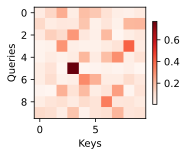

In [2]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    """显示矩阵热图"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False) # axes表示所有子图对象。
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)): 
            # 这部分就是把第(i, j)个矩阵，画到第(i, j)个子图上。
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

# 下面使用一个简单的例子进行演示。在本例子中，仅当查询和键相同时，注意力权重为1，否则为0。
# attention_weights = torch.eye(10).reshape((1, 1, 10, 10))  # torch.eye(10) 生成一个10x10的单位矩阵

# 这部分是随机生成一个$10 \times 10$矩阵并使用`softmax`运算来确保每行都是有效的概率分布，然后可视化输出注意力权重。
matrix = torch.randn(10, 10)
attention_weights = F.softmax(matrix, dim=1).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

### 注意力汇聚：Nadaraya-Watson 核回归

简单起见，考虑下面这个回归问题：
给定的成对的“输入－输出”数据集
$\{(x_1, y_1), \ldots, (x_n, y_n)\}$，
如何学习$f$来预测任意新输入$x$的输出$\hat{y} = f(x)$？

根据下面的非线性函数生成一个人工数据集，
其中加入的噪声项为$\epsilon$：

$$y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon$$

其中$\epsilon$服从均值为$0$和标准差为$0.5$的正态分布。
在这里生成了$50$个训练样本和$50$个测试样本。
为了更好地可视化之后的注意力模式，需要将训练样本进行排序。

In [3]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   
# * 5 的意思是从[0, 1]到[0, 5]
# 排序后的训练样本,默认升序 其中x是数据，_是每个元素在原始张量中的索引位置

In [4]:
def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数

下面的函数将绘制所有的训练样本（样本由圆圈表示），
不带噪声项的真实数据生成函数$f$（标记为“Truth”），
以及学习得到的预测函数（标记为“Pred”）。

In [5]:
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

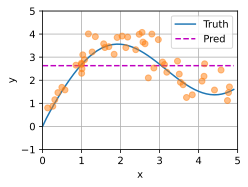

In [9]:
# 我们先试试平均汇聚
y_hat = torch.repeat_interleave(y_train.mean(), n_test) #这样就变成了n_test个均值了 
plot_kernel_reg(y_hat)  # 注：样本由圆圈表示

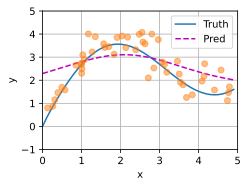

In [15]:
# 基于高斯核的非参数注意力汇聚模型
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))  # 复制x_test，n_train次

# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = F.softmax(-(X_repeat - x_train)**2 / 2, dim=1)

# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

现在来观察注意力的权重。
这里测试数据的输入相当于查询，而训练数据的输入相当于键。

因为两个输入都是经过排序的，因此由观察可知“查询-键”对越接近，
注意力汇聚的注意力权重就越高。

在这里面，$x_{train}$就是$key$,  $y_{train}$就是$value$,  $x_{test}$就是$query$

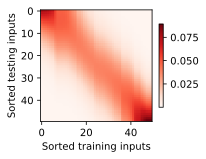

In [16]:
# 可视化注意力的权重，纵坐标代表 query，横坐标代表 key，颜色代表权重值
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),  # unsqueeze 用来在指定的位置添加一个维度（将张量的形状增加一个维度）
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

###  批量矩阵乘法

为了更有效地计算小批量数据的注意力，
我们可以利用深度学习开发框架中提供的批量矩阵乘法。

假设第一个小批量数据包含$n$个矩阵$\mathbf{X}_1,\ldots, \mathbf{X}_n$，
形状为$a\times b$，
第二个小批量包含$n$个矩阵$\mathbf{Y}_1, \ldots, \mathbf{Y}_n$，
形状为$b\times c$。
它们的批量矩阵乘法得到$n$个矩阵
$\mathbf{X}_1\mathbf{Y}_1, \ldots, \mathbf{X}_n\mathbf{Y}_n$，
形状为$a\times c$。
因此，假定两个张量的形状分别是$(n,a,b)$和$(n,b,c)$，
它们的批量矩阵乘法输出的形状为$(n,a,c)$。

In [17]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))

# bmm - batch matrix multiplication
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [20]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))

# unsqueeze 用来在指定的位置添加一个维度（将张量的形状增加一个维度）
# weights.unsqueeze(1) -> (2, 1, 10)
# values.unsqueeze(-1) -> (2, 10, 1)
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))  # (2, 1, 10) * (2, 10, 1) -> (2, 1, 1)

tensor([[[ 4.5000]],

        [[14.5000]]])

## 定义模型

In [23]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))  # 模型中的可训练参数self.w 是一个标量，用于调节核的宽度或“敏感度”

    def forward(self, queries, keys, values):
        # queries 和 attention_weights 的形状为 (查询个数，“键－值”对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))  # 每个 query 被复制了“键－值”对个数次后 reshape
        self.attention_weights = nn.functional.softmax(-((queries - keys) * self.w)**2 / 2, dim=1)  # dim=1 指定沿着键－值对的维度进行 softmax
        # 注：self.w 是一个标量，标量 w 与向量 (queries - keys) 相乘，调整 attention_weights 的分布

        # values 的形状为 (查询个数，“键－值”对个数)
        # 返回值的形状为 (查询个数, 1, 1)
        return torch.bmm(self.attention_weights.unsqueeze(1),  # -> (查询个数, 1, 键－值对个数)
                         values.unsqueeze(-1)).reshape(-1)  # -> (查询个数, 键－值对个数, 1)

注意 queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1])) 的用法非常巧妙。

可以将 queries 重复 keys.shape[1] 次，然后将其展平为 (-1, keys.shape[1]) 的形状，这样就可以将 queries 与 keys 按列拼接起来了。

In [21]:
# 效果示例
queries = torch.tensor([1, 2])  # 假设查询个数为 2，“键－值”对个数为 3
queries.repeat_interleave(3).reshape(-1, 3)

tensor([[1, 1, 1],
        [2, 2, 2]])

### 训练

接下来，将训练数据集变换为键和值用于训练注意力模型。
在带参数的注意力汇聚模型中，
任何一个训练样本的输入都会和除自己以外的所有训练样本的“键－值”对进行计算，
从而得到其对应的预测输出。

In [22]:
# X_tile 形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))  # x_train 被重复 n_train 次
# Y_tile 形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))

# keys 形状:('n_train'，'n_train'-1)
# torch.eye 生成单位矩阵
# 去掉对角线元素（即只保留自己之外的元素），并 reshape
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values 形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

上面这部分代码十分优美，我们可以做以下解释：
<div align="center">
<img src="./imgs/32.png" width="1000" height="600" >
</div>

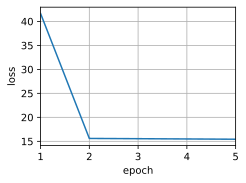

In [24]:
net = NWKernelRegression()
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)  # x_train 为查询(queries)，keys 和 values 为键值对
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    animator.add(epoch + 1, float(l.sum()))

tensor([[0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894],
        [0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894],
        [0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894],
        ...,
        [0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894],
        [0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894],
        [0.1302, 0.2635, 0.3140,  ..., 4.7392, 4.7653, 4.7894]])
tensor([[0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103],
        [0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103],
        [0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103],
        ...,
        [0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103],
        [0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103],
        [0.8012, 0.8719, 1.1558,  ..., 1.1200, 1.4650, 1.7103]])


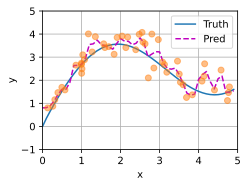

In [ ]:
# keys 形状: (n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
print(keys)

# values 形状: (n_test，n_train)
values = y_train.repeat((n_test, 1))
print(values)

# 在测试集上进行预测
y_hat = net(x_test, keys, values).unsqueeze(1).detach()  # x_test 为查询(queries)，keys 和 values 为键值对

plot_kernel_reg(y_hat)

如图所示，训练完带参数的注意力汇聚模型后可以发现：
在尝试拟合带噪声的训练数据时，
预测结果绘制的线不如之前非参数模型的平滑。

为什么新的模型更不平滑了呢？
下面看一下输出结果的绘制图：
与非参数的注意力汇聚模型相比，
带参数的模型加入可学习的参数后，
曲线在注意力权重较大的区域变得更不平滑。

权重`attention_weights`变得更加集中，
是因为受到参数$w$的影响，
即使得更高的权重集中在查询点的附近，
“窗口”更窄。

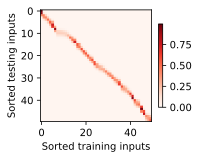

In [28]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

In [29]:
print(net.attention_weights.shape)
# 查看可训练参数 w
net.w  # 起到了扩大查询点周围权重的作用（指数函数特性--爆炸增长）

torch.Size([50, 50])


Parameter containing:
tensor([13.8725], requires_grad=True)

### 掩蔽softmax操作

正如上面提到的，softmax操作用于输出一个概率分布作为注意力权重。
在某些情况下，并非所有的值都应该被纳入到注意力汇聚中。
例如，为了在在机器翻译中高效处理小批量数据集，
某些文本序列被填充了没有意义的特殊词元。
为了仅将有意义的词元作为值来获取注意力汇聚，
可以指定一个有效序列长度（即词元的个数），
以便在计算softmax时过滤掉超出指定范围的位置。
下面的`masked_softmax`函数实现了这样的*掩蔽softmax操作*（masked softmax operation），
其中任何超出有效长度的位置都被掩蔽并置为0。

In [30]:
# 插播下 repeat_interleave 的效果
ri = torch.tensor([1, 2, 3])
torch.repeat_interleave(ri, 2)

tensor([1, 1, 2, 2, 3, 3])

In [ ]:
# 注意：是在最后一个轴（即 feature_dim）上执行掩蔽操作。
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上掩蔽元素来执行softmax操作"""
    # X: 3D 张量。(batch_size, num_steps, feature_dim) 或 (batch_size，查询的个数，“键-值”对的个数)
    # X 可以理解为第 b 个样本中，第 i 个 query 对第 j 个 key 的注意力分数。
    # valid_lens: 1D 或 2D 张量。(batch_size,) 或 (batch_size, num_steps)
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)  # 在最后一个维度进行 softmax 操作
    else:
        shape = X.shape  # (batch_size, num_steps, feature_dim)
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])  # 见上一 chunk 中 repeat_interleave 的用法示例
            # 此时 valid_lens 形状为 (batch_size * num_steps,)
        else:
            valid_lens = valid_lens.reshape(-1)  # 展平为一维，(batch_size * num_steps,)

        # 最后一轴上被掩蔽的元素使用一个非常大的负值替换，从而其 softmax 输出为 0
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]),  # 将 X 的前两维展平为一维 (batch_size * num_steps, feature_dim)
                              valid_lens,
                              value=-1e6)  # e^(-1e6) 趋近于 0
        
        return nn.functional.softmax(X.reshape(shape), dim=-1)

为了演示此函数是如何工作的，
考虑由两个$2 \times 4$矩阵表示的样本，
这两个样本的有效长度分别为$2$和$3$。
经过掩蔽softmax操作，超出有效长度的值都被掩蔽为0。

In [32]:
# 对 X 的最后一个轴（feature_dim）进行掩蔽
# X 形状可理解为 批量大小（batch_size） = 2, 查询个数（queries） = 2, 键值对个数（key_value_num） = 4
# 值的大小代表注意力权重
masked_softmax(torch.rand(2, 2, 4), torch.tensor([2, 3]))

tensor([[[0.4015, 0.5985, 0.0000, 0.0000],
         [0.4007, 0.5993, 0.0000, 0.0000]],

        [[0.4083, 0.2767, 0.3150, 0.0000],
         [0.3403, 0.3771, 0.2826, 0.0000]]])

In [ ]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]])) # 这个是valid_lens为2D张量的形式

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.4124, 0.2589, 0.3287, 0.0000]],

        [[0.4538, 0.5462, 0.0000, 0.0000],
         [0.2559, 0.2787, 0.2436, 0.2218]]])

### 加性注意力

In [35]:
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # 维度扩展前
        # queries 形状：(batch_size，查询的个数，query_size)
        # keys 形状：(batch_size，“键－值”对的个数，key_size)
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 在维度扩展后
        # queries 形状：(batch_size，查询的个数，1，num_hiddens)
        # key 形状：(batch_size，1，“键－值”对的个数，num_hiddens)
        # 使用广播方式进行求和
        features = queries.unsqueeze(2) + keys.unsqueeze(1)  # (batch_size, num_queries, num_kv_pairs, num_hiddens)
        features = torch.tanh(features)
        
        # self.w_v 仅有一个输出，因此从形状中移除最后那个维度
        # scores 形状：(batch_size，查询的个数，“键-值”对的个数)
        scores = self.w_v(features).squeeze(-1)
        # 掩蔽 softmax 操作（即在 key_value_num(“键-值”对的个数) 维度上进行掩蔽）
        self.attention_weights = masked_softmax(scores, valid_lens)

        # values 形状：(batch_size，“键－值”对的个数，值的维度)
        # 返回值形状： (batch_size，查询的个数，值的维度)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [38]:
# queries：2 个批次，每个批次有 1 个查询，每个查询有 20 个特征
# keys：2 个批次，每个批次有 10 个键，每个键有 2 个特征
queries, keys = torch.normal(0, 1, (2, 1, 20)), torch.ones((2, 10, 2))

# values 的小批量，两个值矩阵是相同的
values = torch.arange(40, dtype=torch.float32).reshape(1, 10, 4).repeat(2, 1, 1)  # repeat 后得到 (2, 10, 4)
# 表示第一个批次中只有前 2 个键有效，第二个批次中前 6 个键有效
valid_lens = torch.tensor([2, 6])

attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)
attention.eval()  # 不会启用 dropout
attention(queries, keys, values, valid_lens)  # (batch_size, num_queries, value_size)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

上述大致运算过程如下：

**1.线性变换：**

- queries 和 keys 分别通过线性层 $W_q$ 和 $W_k$ 投影到隐含空间维度（8个特征）。

- 变换后的 queries 形状为 (2, 1, 8)，keys 形状为 (2, 10, 8)。

**2.特征加法：**

- 使用广播机制，将 queries 和 keys 的维度扩展后相加：

- queries 形状扩展为 (2, 1, 1, 8)。

- keys 形状扩展为 (2, 1, 10, 8)。

- 相加后的 features 形状为 (2, 1, 10, 8)，表示每个查询和每个键之间的组合特征。

**3.计算注意力分数：**

- features 经过 tanh 激活函数，然后通过线性层 $w_v$ 压缩为注意力分数。

- scores 的形状为 (2, 1, 10)，表示每个查询和每个键之间的分数。

**4.使用 valid_lens 掩蔽无效键：**

- masked_softmax 函数通过 valid_lens 掩蔽无效的键，将这些位置的分数设置为非常小的值（如 -1e6），对应的 softmax 输出将会是0。
	
**5.计算加权求和值：**

- 对掩蔽后的 scores 进行 softmax，得到 attention_weights，表示注意力权重。

- attention_weights 形状为 (2, 1, 10)，表示每个查询对10个键的权重分布。

- 使用 torch.bmm（批量矩阵乘法），将 attention_weights 和 values 相乘，得到加权求和值。

- 输出的形状为 (2, 1, 4)，表示每个查询的最终加权值（每个值有4个特征）。

最终的结果的2表示为批量大小，1为query的数量，4为vlaue的特征长度。

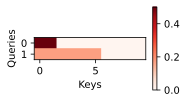

In [ ]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)), # 这边的2可以理解为Q的batch*查询的个数
                  xlabel='Keys', ylabel='Queries')

### 缩放点积注意力

In [45]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries 形状：(batch_size，查询的个数，d)，d 是每个查询的特征维度
    # keys 形状：(batch_size，“键－值”对的个数，d)，d 是每个 key 的特征维度
    # values 形状：(batch_size，“键－值”对的个数，值的维度)
    # valid_lens 形状：(batch_size，) 或者 (batch_size，查询的个数)
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        # transpose 交换 keys 的最后两个维度（转置），以便进行矩阵乘法
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        # scores 形状：(batch_size，查询的个数，“键-值”对的个数)
        # 掩蔽 softmax 操作
        # 在 score 的最后一个维度 key_value_num 进行掩蔽
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [46]:
# queries：2 个批次，每个批次有 1 个查询，每个查询有 2 个特征
queries = torch.normal(0, 1, (2, 1, 2))
# keys：2 个批次，每个批次有 10 个键，每个键有 2 个特征
keys = torch.ones((2, 10, 2))

attention = DotProductAttention(dropout=0.5)
attention.eval()
attention(queries, keys, values, valid_lens)  # (batch_size, num_queries, value_size)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

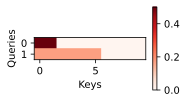

In [47]:
d2l.show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')
# 颜色越深，注意力权重越大
# valid_lens = torch.tensor([2, 6])；故第一个查询只有前两个key-value对具有权重，第二个查询只有前六个键值对具有权重